# Algorithme Apriori — Règles d'association

## 1. Chargement des données et préparation

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

df_sample = pd.read_csv('../data/instacart_sample_clean.csv')

# Reconstruction de la matrice panier par rayon
basket = (
    df_sample
    .groupby(['order_id', 'aisle'])['product_id']
    .count()
    .unstack(fill_value=0)
)
basket = (basket > 0).astype(int)

print(f"Matrice prête : {basket.shape[0]:,} commandes x {basket.shape[1]} rayons")

Matrice prête : 154,792 commandes x 134 rayons


## 2. Extraction des itemsets fréquents
On cherche les combinaisons de rayons qui apparaissent ensemble dans au moins 5% des commandes.

In [4]:
frequent_items = apriori(basket, min_support=0.05, use_colnames=True)
frequent_items = frequent_items.sort_values('support', ascending=False)

print(f"Nombre d'itemsets fréquents trouvés : {len(frequent_items)}")
print(f"\nTop 10 :")
print(frequent_items.head(10).to_string(index=False))

c:\Users\nakhi\anaconda3\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Nombre d'itemsets fréquents trouvés : 152

Top 10 :
 support                                       itemsets
0.552948                                 (fresh fruits)
0.441722                             (fresh vegetables)
0.363720                   (packaged vegetables fruits)
0.314583               (fresh fruits, fresh vegetables)
0.267494     (packaged vegetables fruits, fresh fruits)
0.261428                                       (yogurt)
0.241582                                         (milk)
0.230115 (packaged vegetables fruits, fresh vegetables)
0.228681                              (packaged cheese)
0.190850                (water seltzer sparkling water)


## 3. Génération des règles d'association
On génère les règles avec un lift minimum de 1.2 (association plus forte que le hasard).

**Rappel des métriques :**
- **Support** : fréquence de la combinaison dans les commandes
- **Confidence** : probabilité d'acheter B sachant qu'on a acheté A
- **Lift** : force de l'association (>1 = association positive, 1 = indépendant)

In [5]:
rules = association_rules(frequent_items, metric='lift', min_threshold=1.2)
rules = rules.sort_values('lift', ascending=False)

print(f"Nombre de règles générées : {len(rules)}")
print(f"\nTop 15 règles par lift :")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Nombre de règles générées : 326

Top 15 règles par lift :
                                   antecedents                                    consequents  support  confidence     lift
                                 (fresh herbs)               (fresh fruits, fresh vegetables) 0.061056    0.657232 2.089214
              (fresh fruits, fresh vegetables)                                  (fresh herbs) 0.061056    0.194086 2.089214
                            (fresh vegetables)                    (fresh fruits, fresh herbs) 0.061056    0.138223 2.004292
                   (fresh fruits, fresh herbs)                             (fresh vegetables) 0.061056    0.885340 2.004292
                            (fresh vegetables)                                  (fresh herbs) 0.078731    0.178238 1.918621
                                 (fresh herbs)                             (fresh vegetables) 0.078731    0.847497 1.918621
    (packaged vegetables fruits, fresh fruits)                     (fresh 

## 4. Visualisation des règles

### 4.1 Scatter plot : Support vs Confidence coloré par Lift

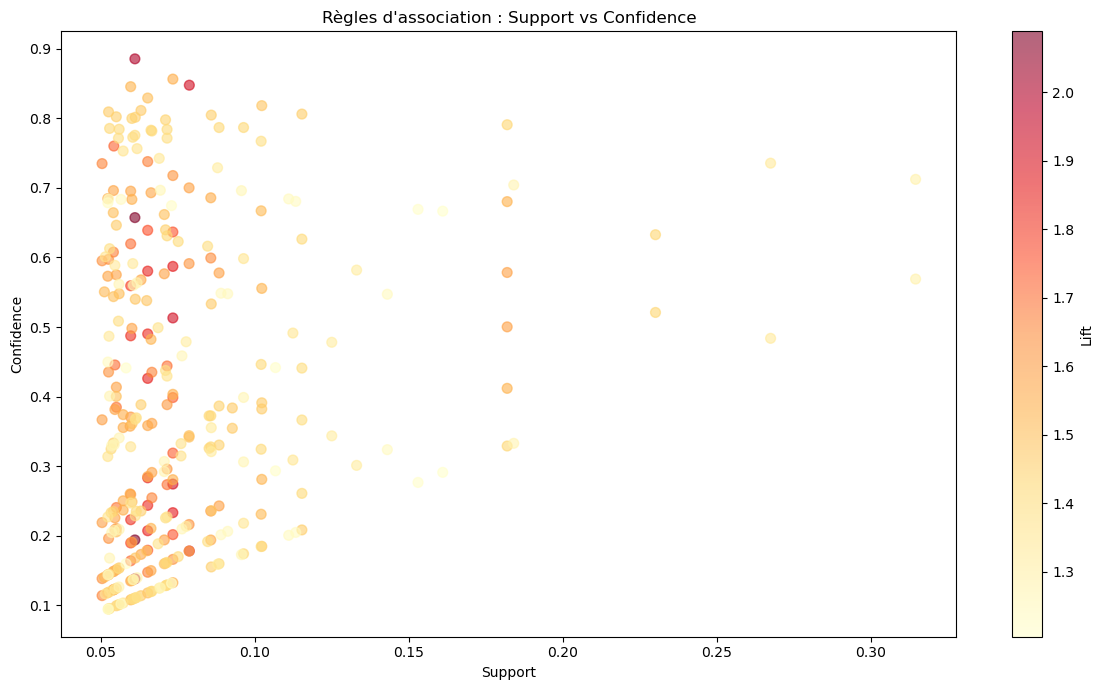

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='YlOrRd',
    alpha=0.6,
    s=50
)
plt.colorbar(scatter, label='Lift')
ax.set_title('Règles d\'association : Support vs Confidence')
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
plt.tight_layout()
plt.savefig('../visual/rules_scatter.png', dpi=150)
plt.show()

### 4.2 Top 15 règles avec le meilleur lift

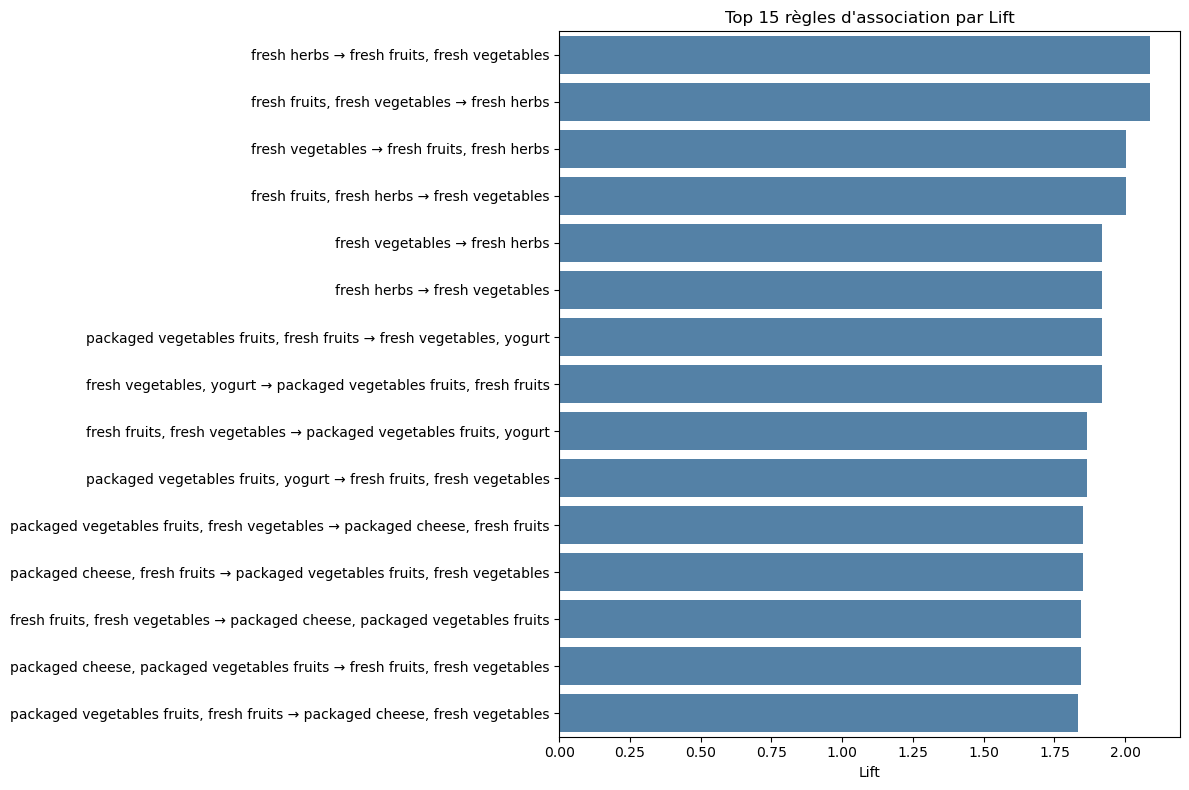

In [8]:
top_rules = rules.head(15).copy()
top_rules['rule'] = (
    top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    + ' → '
    + top_rules['consequents'].apply(lambda x: ', '.join(list(x)))
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_rules, x='lift', y='rule', color='steelblue', ax=ax)
ax.set_title('Top 15 règles d\'association par Lift')
ax.set_xlabel('Lift')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visual/top15_rules_lift.png', dpi=150)
plt.show()

## 5. Filtrage des règles pertinentes

### 5.1 Règles à forte confidence ET lift élevé
On cherche les règles qui sont à la fois fiables (confidence > 40%) et non triviales (lift > 1.5).

In [10]:
filtered_rules = rules[
    (rules['confidence'] >= 0.4) &
    (rules['lift'] >= 1.5)
].sort_values('lift', ascending=False)

print(f"Règles filtrées : {len(filtered_rules)}")
print(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Règles filtrées : 53
                                      antecedents                                    consequents  support  confidence     lift
                                    (fresh herbs)               (fresh fruits, fresh vegetables) 0.061056    0.657232 2.089214
                      (fresh fruits, fresh herbs)                             (fresh vegetables) 0.061056    0.885340 2.004292
                                    (fresh herbs)                             (fresh vegetables) 0.078731    0.847497 1.918621
                       (fresh vegetables, yogurt)     (packaged vegetables fruits, fresh fruits) 0.073382    0.513053 1.917996
             (packaged vegetables fruits, yogurt)               (fresh fruits, fresh vegetables) 0.073382    0.587119 1.866339
                  (packaged cheese, fresh fruits) (packaged vegetables fruits, fresh vegetables) 0.065210    0.426195 1.852093
    (packaged cheese, packaged vegetables fruits)               (fresh fruits, fresh veget

### 5.2 Règles surprenantes (hors fruits/légumes)
On exclut les rayons très fréquents pour trouver des associations moins évidentes.

In [11]:
# Rayons à exclure (trop fréquents, associations triviales)
exclude = {'fresh fruits', 'fresh vegetables'}

surprising_rules = rules[
    rules.apply(lambda row:
        len(row['antecedents'].intersection(exclude)) == 0 and
        len(row['consequents'].intersection(exclude)) == 0,
        axis=1
    )
].sort_values('lift', ascending=False)

print(f"Règles sans fruits/légumes : {len(surprising_rules)}")
print(surprising_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string(index=False))

Règles sans fruits/légumes : 42
                 antecedents                  consequents  support  confidence     lift
           (packaged cheese)                      (bread) 0.059506    0.260212 1.563133
                     (bread)            (packaged cheese) 0.059506    0.357459 1.563133
(packaged vegetables fruits)                (fresh herbs) 0.051146    0.140619 1.513680
               (fresh herbs) (packaged vegetables fruits) 0.051146    0.550556 1.513680
                     (bread)                       (milk) 0.060126    0.361184 1.495078
                      (milk)                      (bread) 0.060126    0.248884 1.495078
(packaged vegetables fruits)       (fresh dips tapenades) 0.054098    0.148736 1.494818
      (fresh dips tapenades) (packaged vegetables fruits) 0.054098    0.543696 1.494818
(packaged vegetables fruits)             (frozen produce) 0.064887    0.178398 1.479170
            (frozen produce) (packaged vegetables fruits) 0.064887    0.538004 1.479170


### 5.3 Visualisation des règles filtrées

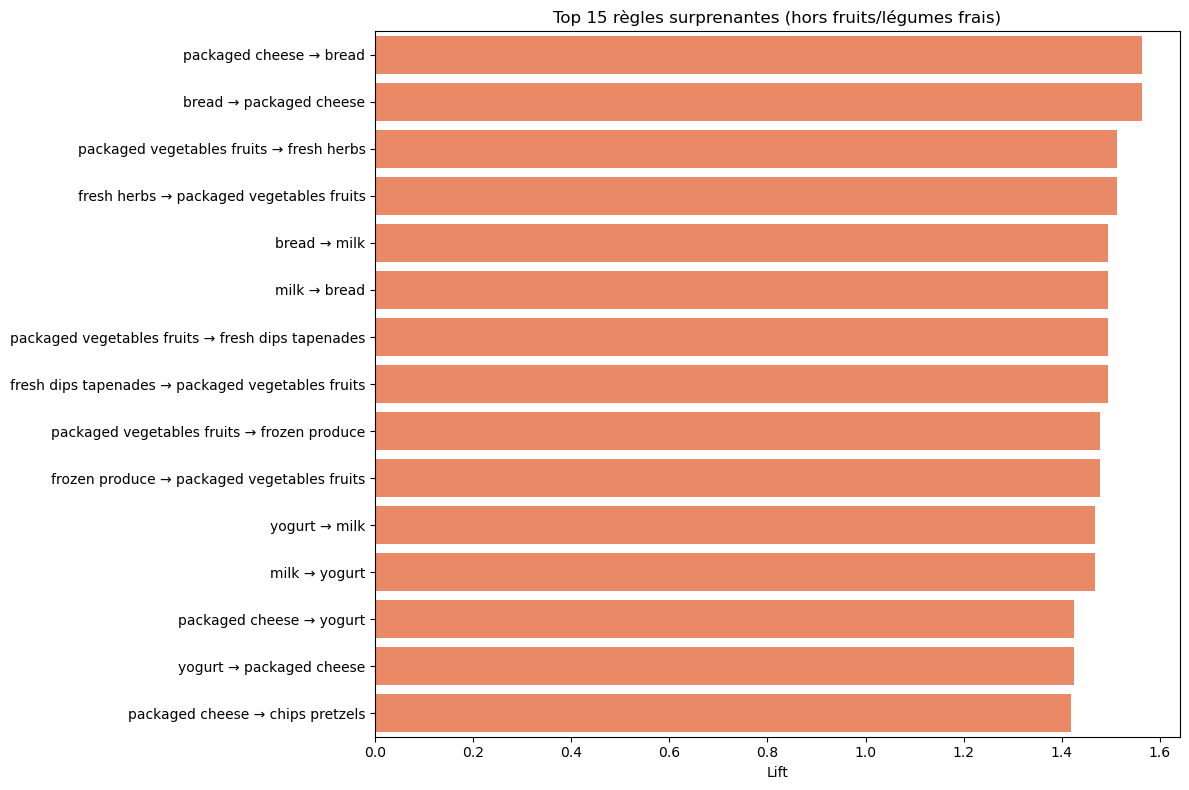

In [12]:
top_surprising = surprising_rules.head(15).copy()
top_surprising['rule'] = (
    top_surprising['antecedents'].apply(lambda x: ', '.join(list(x)))
    + ' → '
    + top_surprising['consequents'].apply(lambda x: ', '.join(list(x)))
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_surprising, x='lift', y='rule', color='coral', ax=ax)
ax.set_title('Top 15 règles surprenantes (hors fruits/légumes frais)')
ax.set_xlabel('Lift')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visual/top15_surprising_rules.png', dpi=150)
plt.show()